In [1]:
import sympy as sp
from collections import defaultdict


# ------------------------------------------------------------
# Pauli algebra
# ------------------------------------------------------------

def multiply_single_pauli(a, b):
    """
    Multiply two single-qubit Pauli operators.
    Returns (phase, resulting_pauli).
    """
    if a == "I":
        return 1, b
    if b == "I":
        return 1, a
    if a == b:
        return 1, "I"

    table = {
        ("X", "Y"): (1j, "Z"),
        ("Y", "X"): (-1j, "Z"),
        ("Y", "Z"): (1j, "X"),
        ("Z", "Y"): (-1j, "X"),
        ("Z", "X"): (1j, "Y"),
        ("X", "Z"): (-1j, "Y"),
    }

    return table[(a, b)]


def multiply_pauli_strings(P, Q):
    """
    Multiply two Pauli strings such as 'IXZY'.
    """
    phase = 1
    result = []

    for p, q in zip(P, Q):
        ph, r = multiply_single_pauli(p, q)
        phase *= ph
        result.append(r)

    return phase, "".join(result)


def multiply_operators(A, B):
    """
    A and B are dictionaries:
        Pauli string -> coefficient
    """
    result = defaultdict(lambda: 0)

    for P, cP in A.items():
        for Q, cQ in B.items():
            phase, R = multiply_pauli_strings(P, Q)
            result[R] += cP * cQ * phase

    return dict(result)


# ------------------------------------------------------------
# Jordan-Wigner operators
# Huggins convention:
#
# n_p = (I + Z_p)/2
#
# a_p^dagger = Z_0 ... Z_{p-1} (X_p + iY_p)/2
# a_p        = Z_0 ... Z_{p-1} (X_p - iY_p)/2
# ------------------------------------------------------------

def jw_creation(p, n):
    X = ["I"] * n
    Y = ["I"] * n

    for j in range(p):
        X[j] = "Z"
        Y[j] = "Z"

    X[p] = "X"
    Y[p] = "Y"

    return {
        "".join(X): sp.Rational(1, 2),
        "".join(Y): sp.I / 2,
    }


def jw_annihilation(p, n):
    X = ["I"] * n
    Y = ["I"] * n

    for j in range(p):
        X[j] = "Z"
        Y[j] = "Z"

    X[p] = "X"
    Y[p] = "Y"

    return {
        "".join(X): sp.Rational(1, 2),
        "".join(Y): -sp.I / 2,
    }


# ------------------------------------------------------------
# Full electronic Hamiltonian
# ------------------------------------------------------------

def jw_electronic_hamiltonian(n):
    """
    Jordan-Wigner transform of

        H = sum_pq h[p,q] a_p^dagger a_q
          + 1/2 sum_pqrs V[p,q,r,s]
                    a_p^dagger a_q^dagger a_r a_s

    using the Huggins convention n_p = (I + Z_p)/2.

    Returns:
        dict:
            Pauli_string -> symbolic coefficient
    """

    H = defaultdict(lambda: 0)

    # -------------------------
    # one-electron part
    # -------------------------
    for p in range(n):
        for q in range(n):

            hpq = sp.Symbol(f"h{p}{q}")

            term = multiply_operators(
                jw_creation(p, n),
                jw_annihilation(q, n)
            )

            for P, coeff in term.items():
                H[P] += hpq * coeff

    # -------------------------
    # two-electron part
    # -------------------------
    for p in range(n):
        for q in range(n):
            for r in range(n):
                for s in range(n):

                    vpqrs = sp.Symbol(f"v{p}{q}{r}{s}")

                    term = jw_creation(p, n)
                    term = multiply_operators(
                        term, jw_creation(q, n)
                    )
                    term = multiply_operators(
                        term, jw_annihilation(r, n)
                    )
                    term = multiply_operators(
                        term, jw_annihilation(s, n)
                    )

                    for P, coeff in term.items():
                        H[P] += sp.Rational(1, 2) * vpqrs * coeff

    # simplify and remove zero terms
    H = {
        P: sp.simplify(c)
        for P, c in H.items()
        if sp.simplify(c) != 0
    }

    return H

In [3]:
H = jw_electronic_hamiltonian(6)

for pauli, coeff in H.items():
    print(pauli, ":", coeff)

IIIIII : h00/2 + h11/2 + h22/2 + h33/2 + h44/2 + h55/2 - 0.125*v0101 + 0.125*v0110 - 0.125*v0202 + 0.125*v0220 - 0.125*v0303 + 0.125*v0330 - 0.125*v0404 + 0.125*v0440 - 0.125*v0505 + 0.125*v0550 + 0.125*v1001 - 0.125*v1010 - 0.125*v1212 + 0.125*v1221 - 0.125*v1313 + 0.125*v1331 - 0.125*v1414 + 0.125*v1441 - 0.125*v1515 + 0.125*v1551 + 0.125*v2002 - 0.125*v2020 + 0.125*v2112 - 0.125*v2121 - 0.125*v2323 + 0.125*v2332 - 0.125*v2424 + 0.125*v2442 - 0.125*v2525 + 0.125*v2552 + 0.125*v3003 - 0.125*v3030 + 0.125*v3113 - 0.125*v3131 + 0.125*v3223 - 0.125*v3232 - 0.125*v3434 + 0.125*v3443 - 0.125*v3535 + 0.125*v3553 + 0.125*v4004 - 0.125*v4040 + 0.125*v4114 - 0.125*v4141 + 0.125*v4224 - 0.125*v4242 + 0.125*v4334 - 0.125*v4343 - 0.125*v4545 + 0.125*v4554 + 0.125*v5005 - 0.125*v5050 + 0.125*v5115 - 0.125*v5151 + 0.125*v5225 - 0.125*v5252 + 0.125*v5335 - 0.125*v5353 + 0.125*v5445 - 0.125*v5454
ZIIIII : 0.5*h00 - 0.125*v0101 + 0.125*v0110 - 0.125*v0202 + 0.125*v0220 - 0.125*v0303 + 0.125*v0330 - 0.

XY weight distribution:
weight 0: 56 terms
weight 2: 1620 terms
weight 4: 3360 terms

XYZ weight distribution:
weight 0: 1 terms
weight 1: 10 terms
weight 2: 113 terms
weight 3: 376 terms
weight 4: 772 terms
weight 5: 944 terms
weight 6: 940 terms
weight 7: 808 terms
weight 8: 596 terms
weight 9: 352 terms
weight 10: 124 terms


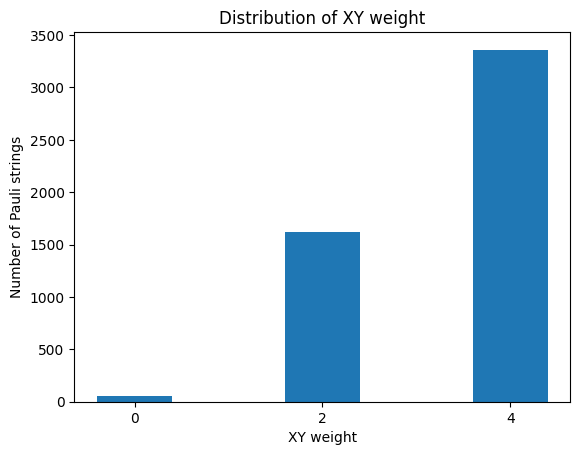

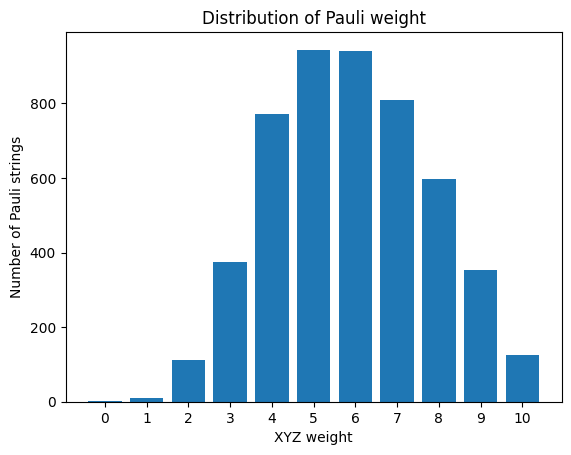

In [8]:
from collections import Counter
import matplotlib.pyplot as plt

H = jw_electronic_hamiltonian(10)

# Weight definitions
def xy_weight(pauli_string):
    return sum(c in "XY" for c in pauli_string)

def xyz_weight(pauli_string):
    return sum(c in "XYZ" for c in pauli_string)


# Distribution = number of Hamiltonian terms having each weight
xy_dist = Counter(xy_weight(P) for P in H)
xyz_dist = Counter(xyz_weight(P) for P in H)

print("XY weight distribution:")
for w in sorted(xy_dist):
    print(f"weight {w}: {xy_dist[w]} terms")

print("\nXYZ weight distribution:")
for w in sorted(xyz_dist):
    print(f"weight {w}: {xyz_dist[w]} terms")

# XY-weight distribution
plt.figure()
plt.bar(sorted(xy_dist), [xy_dist[w] for w in sorted(xy_dist)])
plt.xlabel("XY weight")
plt.ylabel("Number of Pauli strings")
plt.title("Distribution of XY weight")
plt.xticks(sorted(xy_dist))
plt.show()


# XYZ-weight distribution
plt.figure()
plt.bar(sorted(xyz_dist), [xyz_dist[w] for w in sorted(xyz_dist)])
plt.xlabel("XYZ weight")
plt.ylabel("Number of Pauli strings")
plt.title("Distribution of Pauli weight")
plt.xticks(sorted(xyz_dist))
plt.show()